,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


Баланс классов
SeriousDlqin2yrs
0    93.316
1     6.684
Name: proportion, dtype: float64


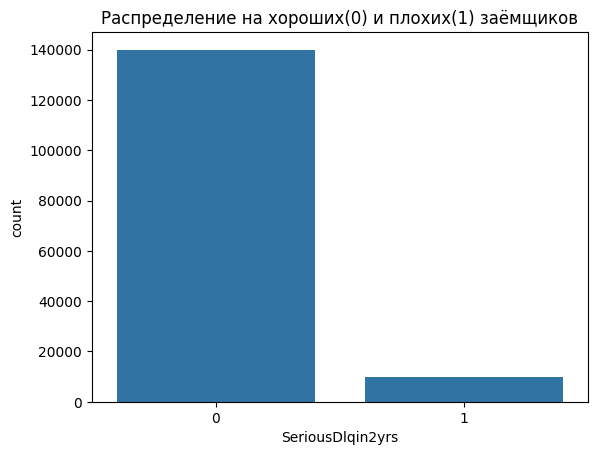

Пропущенные значения
SeriousDlqin2yrs                            0
RevolvingUtilizationOfUnsecuredLines        0
age                                         0
NumberOfTime30-59DaysPastDueNotWorse        0
DebtRatio                                   0
MonthlyIncome                           29731
NumberOfOpenCreditLinesAndLoans             0
NumberOfTimes90DaysLate                     0
NumberRealEstateLoansOrLines                0
NumberOfTime60-89DaysPastDueNotWorse        0
NumberOfDependents                       3924
dtype: int64


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score

df = pd.read_csv('../data/raw/cs-training.csv', index_col=0)
display(df.head())

print("Баланс классов")
class_balance = df['SeriousDlqin2yrs'].value_counts(normalize=True) * 100
print(class_balance)

sns.countplot(x='SeriousDlqin2yrs', data=df)
plt.title('Распределение на хороших(0) и плохих(1) заёмщиков')
plt.show()

print("Пропущенные значения")
print(df.isnull().sum())

In [9]:
mean_income = df['MonthlyIncome'].mean()
median_income = df['MonthlyIncome'].median()

print(f"Средний доход: {mean_income:.2f}")
print(f"Медианный доход: {median_income:.2f}")

df['MonthlyIncome'] = df['MonthlyIncome'].fillna(median_income)

print(f"Оставшиеся пропуски в доходах: {df['MonthlyIncome'].isnull().sum()}")
print(f"пропуски в numOfDepend: {df['NumberOfDependents'].isnull().sum()}")

Средний доход: 6670.22
Медианный доход: 5400.00
Оставшиеся пропуски в доходах: 0
пропуски в numOfDepend: 3924


In [10]:
mean_depend = df['NumberOfDependents'].mean()
median_depend = df['NumberOfDependents'].median()

print(f"Средние кол-во иждивенцев: {mean_depend:.2f}")
print(f"Медиана кол-ва иждивенцев: {median_depend:.2f}")

df['NumberOfDependents'] = df['NumberOfDependents'].fillna(mean_depend)

print(f"пропуски в numOfDepend: {df['NumberOfDependents'].isnull().sum()}")

Средние кол-во иждивенцев: 0.76
Медиана кол-ва иждивенцев: 0.00
пропуски в numOfDepend: 0


In [28]:
y = df['SeriousDlqin2yrs']
X = df.drop('SeriousDlqin2yrs', axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
model.fit(X_train_scaled, y_train)

y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
y_pred_class = model.predict(X_test_scaled)

print(f"Вероятности дефолта(1): {y_pred_proba.T}")
print(f"Метки: {y_pred_class.T}")

print(f"Accuracy (доля правильных ответов): {accuracy_score(y_test, y_pred_class):.4f}")
print(f"ROC-AUC (Способность модели ранжировать клиентов): {roc_auc_score(y_test, y_pred_proba):.4f}")

Вероятности дефолта(1): [0.2755034  0.24618405 0.29727284 ... 0.53544968 0.21919665 0.56466883]
Метки: [0 0 0 ... 1 0 1]
Accuracy (доля правильных ответов): 0.7766
ROC-AUC (Способность модели ранжировать клиентов): 0.8022
